# 🪔 Diwali Sales Analysis
**Objective:** Analyze customer purchasing behaviour during Diwali festive season to uncover revenue trends, top categories, and customer segments.

**Dataset:** 1000 customer records | Features: Gender, Age Group, State, Occupation, Product Category, Orders, Amount, Rating

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
print("Libraries loaded successfully!")

Libraries loaded successfully!


## 1. Load & Explore Dataset

In [2]:
df = pd.read_csv("diwali_sales.csv")
print("Shape:", df.shape)
df.head()

Shape: (1000, 11)


,Customer_ID,Gender,Age_Group,State,Marital_Status,Occupation,Product_Category,Orders,Amount,Rating,Total_Revenue
0,CID0001,Male,18-25,Maharashtra,Married,Student,Food & Sweets,3,970.0,5,2910.0
1,CID0002,Female,26-35,Maharashtra,Married,Homemaker,Toys & Games,1,1010.0,4,1010.0
2,CID0003,Female,46-55,Tamil Nadu,Unmarried,Homemaker,Clothing,3,3490.0,5,10470.0
3,CID0004,Female,36-45,Maharashtra,Married,IT Professional,Food & Sweets,3,950.0,4,2850.0
4,CID0005,Male,46-55,Maharashtra,Unmarried,IT Professional,Food & Sweets,1,660.0,4,660.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Customer_ID       1000 non-null   object 
 1   Gender            1000 non-null   object 
 2   Age_Group         1000 non-null   object 
 3   State             1000 non-null   object 
 4   Marital_Status    1000 non-null   object 
 5   Occupation        1000 non-null   object 
 6   Product_Category  1000 non-null   object 
 7   Orders            1000 non-null   int64  
 8   Amount            1000 non-null   float64
 9   Rating            1000 non-null   int64  
 10  Total_Revenue     1000 non-null   float64
dtypes: float64(2), int64(2), object(7)
memory usage: 86.1+ KB


In [4]:
df.isnull().sum()

Customer_ID         0
Gender              0
Age_Group           0
State               0
Marital_Status      0
Occupation          0
Product_Category    0
Orders              0
Amount              0
Rating              0
Total_Revenue       0
dtype: int64

In [5]:
df.describe()

,Orders,Amount,Rating,Total_Revenue
count,1000.000000,1000.000000,1000.000000,1000.00000
mean,2.921000,6044.420000,4.261000,16922.54000
std,1.458385,6218.600136,0.712311,20952.21803
min,1.000000,570.000000,3.000000,570.00000
25%,2.000000,1570.000000,4.000000,3600.00000
50%,3.000000,3100.000000,4.000000,8850.00000
75%,4.000000,10047.500000,5.000000,19500.00000
max,5.000000,22480.000000,5.000000,111350.00000


## 2. Revenue by Product Category

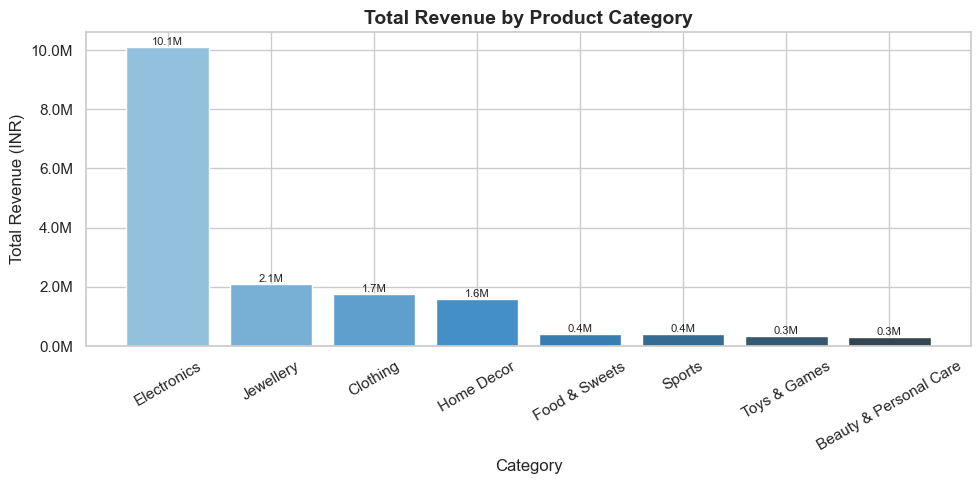

Top Category: Electronics with 10,093,070 revenue


In [6]:
cat_rev = df.groupby("Product_Category")["Total_Revenue"].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10,5))
bars = ax.bar(cat_rev.index, cat_rev.values, color=sns.color_palette("Blues_d", len(cat_rev)))
ax.set_title("Total Revenue by Product Category", fontsize=14, fontweight="bold")
ax.set_xlabel("Category")
ax.set_ylabel("Total Revenue (INR)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x/1e6:.1f}M"))
plt.xticks(rotation=30)
for bar in bars:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+20000,
            f"{bar.get_height()/1e6:.1f}M", ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.show()
print(f"Top Category: {cat_rev.idxmax()} with {cat_rev.max():,.0f} revenue")

## 3. Top 7 States by Revenue

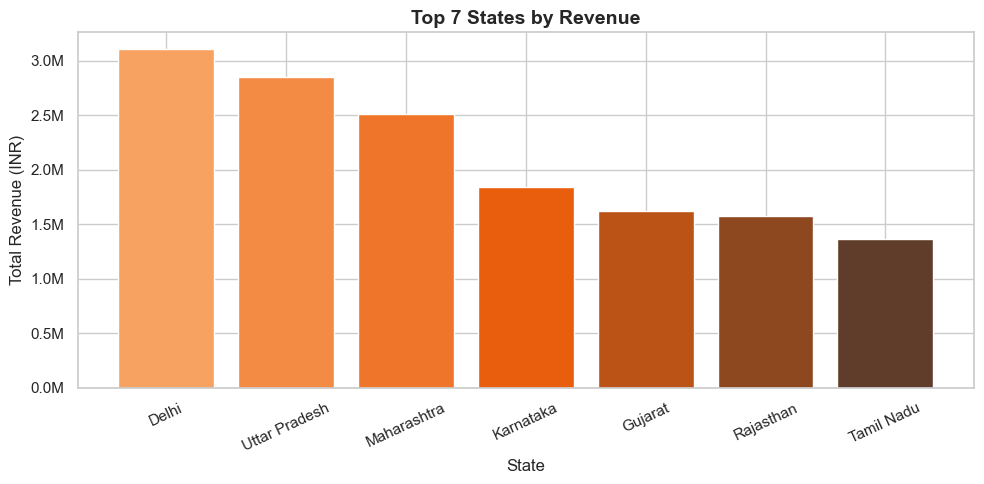

Top State: Delhi


In [7]:
state_rev = df.groupby("State")["Total_Revenue"].sum().sort_values(ascending=False).head(7)

fig, ax = plt.subplots(figsize=(10,5))
ax.bar(state_rev.index, state_rev.values, color=sns.color_palette("Oranges_d", 7))
ax.set_title("Top 7 States by Revenue", fontsize=14, fontweight="bold")
ax.set_xlabel("State")
ax.set_ylabel("Total Revenue (INR)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x/1e6:.1f}M"))
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()
print(f"Top State: {state_rev.idxmax()}")

## 4. Gender-wise Spending Across Categories

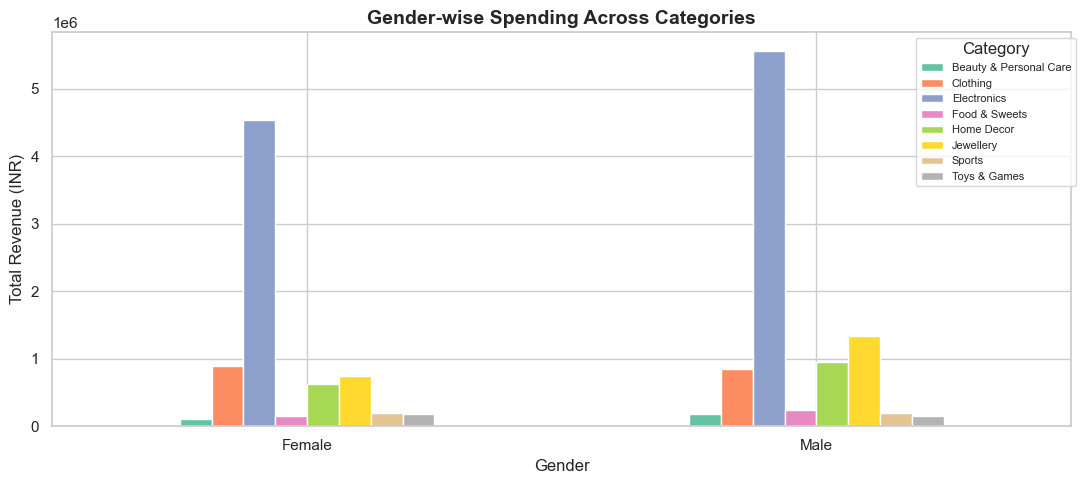

In [8]:
gender_data = df.groupby(["Gender","Product_Category"])["Total_Revenue"].sum().unstack()
gender_data.plot(kind="bar", figsize=(11,5), colormap="Set2")
plt.title("Gender-wise Spending Across Categories", fontsize=14, fontweight="bold")
plt.xlabel("Gender")
plt.ylabel("Total Revenue (INR)")
plt.legend(title="Category", bbox_to_anchor=(1.01,1), fontsize=8)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 5. Revenue by Age Group

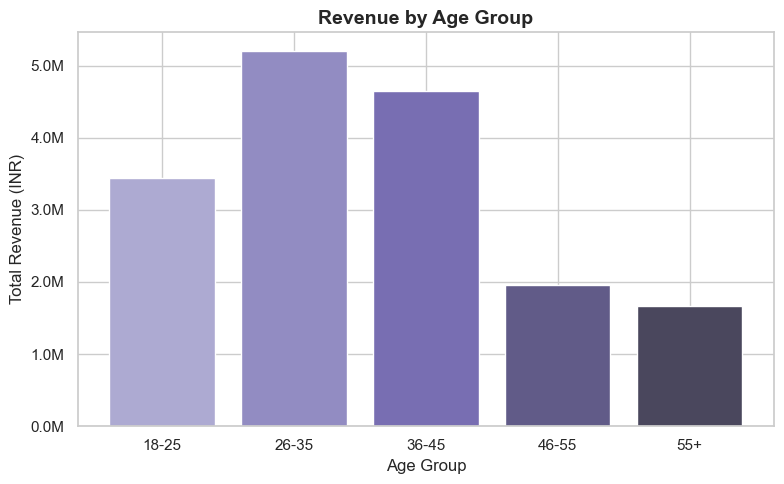

Highest Spending Age Group: 26-35


In [9]:
age_order = ["18-25","26-35","36-45","46-55","55+"]
age_rev = df.groupby("Age_Group")["Total_Revenue"].sum().reindex(age_order)

fig, ax = plt.subplots(figsize=(8,5))
ax.bar(age_rev.index, age_rev.values, color=sns.color_palette("Purples_d", 5))
ax.set_title("Revenue by Age Group", fontsize=14, fontweight="bold")
ax.set_xlabel("Age Group")
ax.set_ylabel("Total Revenue (INR)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x/1e6:.1f}M"))
plt.tight_layout()
plt.show()
print(f"Highest Spending Age Group: {age_rev.idxmax()}")

## 6. Revenue by Occupation

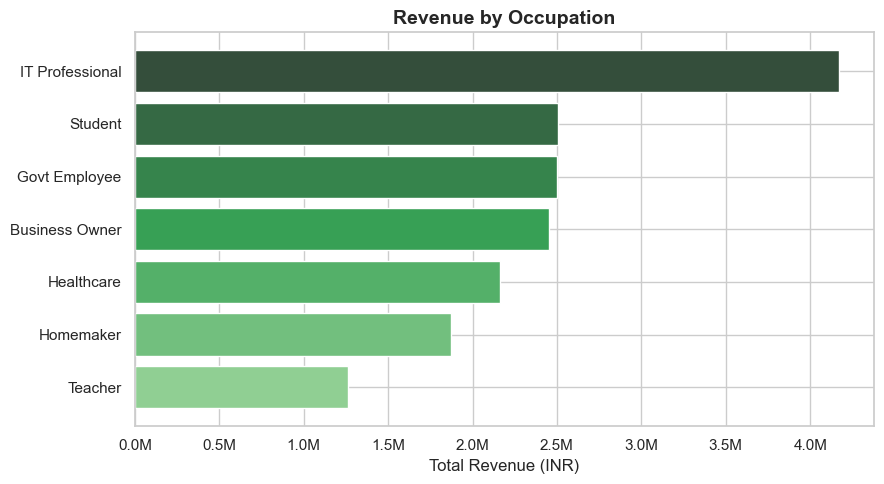

Top Spending Occupation: IT Professional


In [10]:
occ_rev = df.groupby("Occupation")["Total_Revenue"].sum().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9,5))
ax.barh(occ_rev.index, occ_rev.values, color=sns.color_palette("Greens_d", len(occ_rev)))
ax.set_title("Revenue by Occupation", fontsize=14, fontweight="bold")
ax.set_xlabel("Total Revenue (INR)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x/1e6:.1f}M"))
plt.tight_layout()
plt.show()
print(f"Top Spending Occupation: {occ_rev.idxmax()}")

## 7. Marital Status & Gender vs Avg Order Value

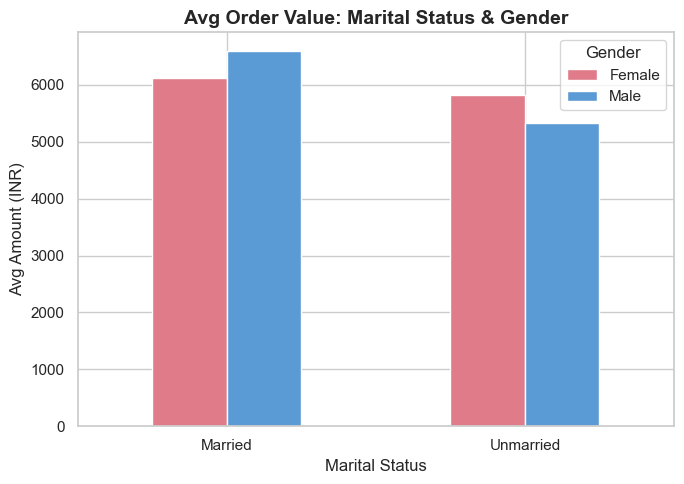

In [11]:
marital_avg = df.groupby(["Marital_Status","Gender"])["Amount"].mean().unstack()
marital_avg.plot(kind="bar", figsize=(7,5), color=["#E07B8A","#5B9BD5"])
plt.title("Avg Order Value: Marital Status & Gender", fontsize=14, fontweight="bold")
plt.xlabel("Marital Status")
plt.ylabel("Avg Amount (INR)")
plt.xticks(rotation=0)
plt.legend(title="Gender")
plt.tight_layout()
plt.show()

## 8. Customer Rating Distribution

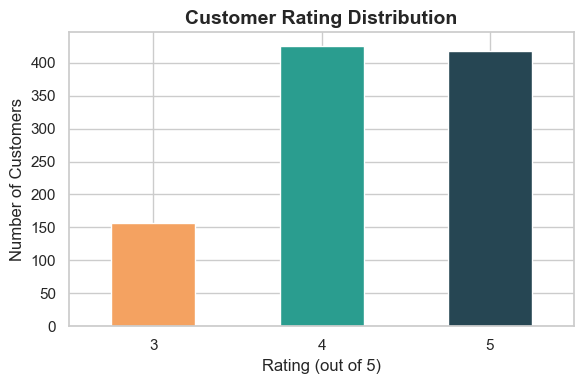

In [12]:
fig, ax = plt.subplots(figsize=(6,4))
df["Rating"].value_counts().sort_index().plot(kind="bar",
    color=["#f4a261","#2a9d8f","#264653"], ax=ax)
ax.set_title("Customer Rating Distribution", fontsize=14, fontweight="bold")
ax.set_xlabel("Rating (out of 5)")
ax.set_ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 9. Key Insights Summary

In [14]:
print("=" * 50)
print("      DIWALI SALES - KEY INSIGHTS")
print("=" * 50)

total_rev = df["Total_Revenue"].sum()
total_cust = len(df)
total_orders = df["Orders"].sum()
avg_order = df["Amount"].mean()
top_cat = df.groupby("Product_Category")["Total_Revenue"].sum().idxmax()
top_state = df.groupby("State")["Total_Revenue"].sum().idxmax()
top_age = df.groupby("Age_Group")["Total_Revenue"].sum().idxmax()
top_occ = df.groupby("Occupation")["Total_Revenue"].sum().idxmax()
avg_rating = df["Rating"].mean()

print(f"Total Revenue    : {total_rev:,.0f} INR")
print(f"Total Customers  : {total_cust:,}")
print(f"Total Orders     : {total_orders:,}")
print(f"Avg Order Value  : {avg_order:,.0f} INR")
print(f"Top Category     : {top_cat}")
print(f"Top State        : {top_state}")
print(f"Top Age Group    : {top_age}")
print(f"Top Occupation   : {top_occ}")
print(f"Avg Rating       : {avg_rating:.2f} / 5")
print("=" * 50)

      DIWALI SALES - KEY INSIGHTS
Total Revenue    : 16,922,540 INR
Total Customers  : 1,000
Total Orders     : 2,921
Avg Order Value  : 6,044 INR
Top Category     : Electronics
Top State        : Delhi
Top Age Group    : 26-35
Top Occupation   : IT Professional
Avg Rating       : 4.26 / 5
